# 实验五：Kaggle 车辆图像分类（CNN 对照 + VGG16 迁移学习微调）

本 Notebook 对应 D5《实验迁移学习 2026》的 Kaggle 任务：读取 `emergency_train.csv` 中的图片路径与类别，完成车辆图片分类，并进行以下对比。

1. 训练一个两层卷积的普通 CNN 作为对照组；
2. 加载 ImageNet 预训练的 VGG16-BN，先冻结预训练层、训练新分类头；
3. 解冻最后一个卷积块，用更小学习率进行微调；
4. 比较两种模型的验证准确率，并用微调后的 VGG16-BN 生成提交文件。

运行前请在 Kaggle Notebook 中完成：

- 右侧 **Add Input** 添加本次课程竞赛数据；
- **Settings → Accelerator → GPU T4**；
- 若 `/kaggle/input` 中没有 VGG16-BN 权重文件，请打开 **Internet**，让 TorchVision 首次下载 ImageNet 权重。

代码不会依赖课件中的占位目录名。它会读取实际 CSV 表头，自动定位训练 CSV、测试 CSV、图片目录和 sample submission。最终文件保存为 `/kaggle/working/submission.csv`。


In [30]:
import os
import random
import re
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from torchvision.models import VGG16_BN_Weights

SEED = 42
IMAGE_SIZE = 224

# D5 课件的普通 CNN 为 15 个 epoch；迁移学习共 15 个 epoch（10 + 5）。
CNN_EPOCHS = 15
HEAD_EPOCHS = 10
FINETUNE_EPOCHS = 5

# 调试数据流程时可改为 True；正式提交必须保持 False 后重新 Run All。
FAST_DEV_RUN = False
REQUIRE_GPU = True
EXPECTED_SUBMISSION_ROWS = 165


def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = torch.cuda.is_available()


def select_device(require_gpu=REQUIRE_GPU):
    if not torch.cuda.is_available():
        message = "CUDA 不可用。请在 Kaggle Settings → Accelerator 中选择 GPU T4，重启会话后 Run All。"
        if require_gpu:
            raise RuntimeError(message)
        print(message, "当前继续使用 CPU，但 VGG16 会非常慢。")
        return torch.device("cpu")

    gpu_name = torch.cuda.get_device_name(0)
    capability = torch.cuda.get_device_capability(0)
    gpu_arch = f"sm_{capability[0]}{capability[1]}"
    compiled_arches = set(torch.cuda.get_arch_list())
    print("GPU:", gpu_name, "架构:", gpu_arch)
    print("当前 PyTorch 支持的 CUDA 架构:", sorted(compiled_arches))

    if compiled_arches and gpu_arch not in compiled_arches:
        raise RuntimeError(
            f"当前 PyTorch 未包含 {gpu_arch} 的 CUDA 内核。"
            "请把 Kaggle Accelerator 改为 GPU T4，Restart Session 后重新 Run All。"
        )

    try:
        probe = nn.Conv2d(3, 4, kernel_size=3, padding=1).cuda()
        _ = probe(torch.zeros(1, 3, 16, 16, device="cuda")).sum().item()
        del probe
        torch.cuda.empty_cache()
    except Exception as error:
        raise RuntimeError(
            "CUDA 卷积测试失败。请改用 Kaggle GPU T4 并重启会话。"
        ) from error
    return torch.device("cuda")


seed_everything()
DEVICE = select_device()
OUTPUT_DIR = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path.cwd()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("PyTorch:", torch.__version__)
print("TorchVision:", __import__("torchvision").__version__)
print("设备:", DEVICE)
print("输出目录:", OUTPUT_DIR)


GPU: Tesla T4 架构: sm_75
当前 PyTorch 支持的 CUDA 架构: ['sm_100', 'sm_120', 'sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90']
PyTorch: 2.10.0+cu128
TorchVision: 0.25.0+cu128
设备: cuda
输出目录: /kaggle/working


## 1. 自动定位竞赛数据

D5 课件示例使用 `image_names` 和 `emergency_or_not`，但课程竞赛可能重命名文件或提交列。下面的代码按**实际表头**识别文件：

- 训练 CSV：同时包含图片名列和标签列；
- 测试 CSV：包含图片名列但不含标签列；
- sample submission：优先保留它的列名、ID 与行顺序；
- 如果没有测试 CSV，则使用“图片目录中未被训练 CSV 引用的图片”作为测试集。


In [31]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
IMAGE_COLUMN_NAMES = [
    "image_names", "image_name", "filename", "file_name", "image", "file", "path"
]
LABEL_COLUMN_NAMES = ["emergency_or_not", "label", "target", "class"]


def normalized_columns(df):
    return {str(column).strip().lower(): column for column in df.columns}


def pick_named_column(df, candidates):
    columns = normalized_columns(df)
    for candidate in candidates:
        if candidate in columns:
            return columns[candidate]
    return None


def inspect_csv(path):
    try:
        frame = pd.read_csv(path, nrows=32)
    except Exception:
        return None
    if frame.empty and len(frame.columns) == 0:
        return None
    return {
        "path": path,
        "columns": list(frame.columns),
        "image_col": pick_named_column(frame, IMAGE_COLUMN_NAMES),
        "label_col": pick_named_column(frame, LABEL_COLUMN_NAMES),
    }


def path_priority(path):
    text = str(path).lower().replace("-", "").replace("_", "")
    keywords = ["zjutest5", "emergency", "vehicle", "d5"]
    return -sum(keyword in text for keyword in keywords), len(path.parts), str(path)


def find_competition_files():
    env_root = os.environ.get("D5_INPUT_ROOT")
    search_root = Path(env_root).expanduser() if env_root else Path("/kaggle/input")
    if not search_root.exists():
        raise FileNotFoundError(
            f"输入根目录不存在：{search_root}。请先在 Kaggle 右侧 Add Input 添加实验五竞赛数据。"
        )

    csv_paths = sorted(search_root.rglob("*.csv"))
    infos = [info for path in csv_paths if (info := inspect_csv(path)) is not None]
    train_candidates = [
        info
        for info in infos
        if info["image_col"] is not None
        and info["label_col"] is not None
        and "sample" not in info["path"].name.lower()
        and "submission" not in info["path"].name.lower()
    ]
    if not train_candidates:
        visible = [(str(info["path"]), info["columns"]) for info in infos[:30]]
        raise FileNotFoundError(
            "没有找到同时包含图片名列和标签列的训练 CSV。"
            f"已检查的 CSV（最多 30 个）：{visible}"
        )

    train_info = sorted(train_candidates, key=lambda info: path_priority(info["path"]))[0]
    if env_root:
        dataset_dir = search_root
    else:
        relative_train_path = train_info["path"].relative_to(search_root)
        dataset_dir = (
            search_root / relative_train_path.parts[0]
            if len(relative_train_path.parts) > 1
            else train_info["path"].parent
        )

    local_infos = [info for info in infos if dataset_dir in info["path"].parents or info["path"].parent == dataset_dir]
    sample_candidates = [
        info
        for info in local_infos
        if "sample" in info["path"].name.lower()
        or "submission" in info["path"].name.lower()
        or info["path"].stem.lower() in {"sub", "submit"}
    ]
    sample_info = sorted(sample_candidates, key=lambda info: str(info["path"]))[0] if sample_candidates else None

    test_candidates = [
        info
        for info in local_infos
        if info["path"] != train_info["path"]
        and info["image_col"] is not None
        and info["label_col"] is None
        and info is not sample_info
    ]
    test_info = sorted(test_candidates, key=lambda info: path_priority(info["path"]))[0] if test_candidates else None
    return search_root, dataset_dir, train_info, test_info, sample_info


INPUT_ROOT, DATASET_DIR, TRAIN_INFO, TEST_INFO, SAMPLE_INFO = find_competition_files()

print("输入根目录:", INPUT_ROOT)
print("数据集目录:", DATASET_DIR)
print("训练 CSV:", TRAIN_INFO["path"], TRAIN_INFO["columns"])
print("测试 CSV:", None if TEST_INFO is None else (TEST_INFO["path"], TEST_INFO["columns"]))
print("提交模板:", None if SAMPLE_INFO is None else (SAMPLE_INFO["path"], SAMPLE_INFO["columns"]))


输入根目录: /kaggle/input
数据集目录: /kaggle/input/competitions
训练 CSV: /kaggle/input/competitions/2026zjutest5/emergency_train.csv ['image_names', 'emergency_or_not']
测试 CSV: None
提交模板: None


In [32]:
train_df = pd.read_csv(TRAIN_INFO["path"])
test_df = None if TEST_INFO is None else pd.read_csv(TEST_INFO["path"])
sample_df = None if SAMPLE_INFO is None else pd.read_csv(SAMPLE_INFO["path"])

TRAIN_IMAGE_COL = TRAIN_INFO["image_col"]
LABEL_COL = TRAIN_INFO["label_col"]

if train_df[TRAIN_IMAGE_COL].isna().any() or train_df[LABEL_COL].isna().any():
    raise ValueError("训练 CSV 的图片名列或标签列存在缺失值，请先检查数据。")

class_values = sorted(train_df[LABEL_COL].unique().tolist(), key=lambda value: str(value))
NUM_CLASSES = len(class_values)
if NUM_CLASSES < 2:
    raise ValueError(f"训练集至少需要两个类别，实际标签为：{class_values}")

label_to_index = {value: index for index, value in enumerate(class_values)}
index_to_label = {index: value for value, index in label_to_index.items()}
y_all = train_df[LABEL_COL].map(label_to_index).to_numpy(dtype=np.int64)


def natural_key(value):
    return [int(part) if part.isdigit() else part.lower() for part in re.split(r"(\d+)", str(value))]


all_image_paths = sorted(
    [path for path in DATASET_DIR.rglob("*") if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS],
    key=lambda path: natural_key(path.relative_to(DATASET_DIR)),
)
if not all_image_paths:
    raise FileNotFoundError(f"在 {DATASET_DIR} 下没有找到图片文件。")

relative_index = {str(path.relative_to(DATASET_DIR)).replace("\\", "/").lower(): path for path in all_image_paths}
basename_index = {}
stem_index = {}
for path in all_image_paths:
    basename_index.setdefault(path.name.lower(), []).append(path)
    stem_index.setdefault(path.stem.lower(), []).append(path)


def resolve_image(reference):
    reference = str(reference).strip().replace("\\", "/")
    direct = DATASET_DIR / reference
    if direct.is_file():
        return direct
    relative_match = relative_index.get(reference.lower())
    if relative_match is not None:
        return relative_match
    matches = basename_index.get(Path(reference).name.lower(), [])
    if len(matches) == 1:
        return matches[0]
    if len(matches) > 1:
        raise ValueError(f"图片名 {reference!r} 在数据集中重复，请在 CSV 中保留相对目录。")
    raise FileNotFoundError(f"CSV 引用的图片不存在：{reference}")


train_references = train_df[TRAIN_IMAGE_COL].astype(str).tolist()
train_paths = [resolve_image(reference) for reference in train_references]
train_path_set = {path.resolve() for path in train_paths}


def order_test_references():
    if test_df is not None:
        test_image_col = TEST_INFO["image_col"]
        references = test_df[test_image_col].astype(str).tolist()

        # 若 sample 第一列对应 test.csv 中某个 ID 列，则严格按 sample 的顺序重排测试图片。
        if sample_df is not None and len(sample_df) == len(test_df):
            sample_ids = sample_df.iloc[:, 0].astype(str)
            for column in test_df.columns:
                test_ids = test_df[column].astype(str)
                if test_ids.is_unique and set(test_ids) == set(sample_ids):
                    mapping = dict(zip(test_ids, test_df[test_image_col].astype(str)))
                    return [mapping[value] for value in sample_ids]
        return references

    remaining = [path for path in all_image_paths if path.resolve() not in train_path_set]
    if not remaining:
        raise FileNotFoundError("没有测试 CSV，也没有发现训练集之外的图片。")

    if sample_df is not None:
        sample_ids = sample_df.iloc[:, 0].astype(str).tolist()
        matched = []
        for value in sample_ids:
            candidates = basename_index.get(Path(value).name.lower(), [])
            if not candidates:
                candidates = stem_index.get(Path(value).stem.lower(), [])
            candidates = [path for path in candidates if path.resolve() not in train_path_set]
            if len(candidates) == 1:
                matched.append(str(candidates[0].relative_to(DATASET_DIR)))
            else:
                matched = []
                break
        if matched:
            return matched
        if len(remaining) != len(sample_df):
            raise ValueError(
                f"sample submission 有 {len(sample_df)} 行，但发现 {len(remaining)} 张未标注图片，无法确定测试顺序。"
            )

    return [str(path.relative_to(DATASET_DIR)) for path in remaining]


test_references = order_test_references()
test_paths = [resolve_image(reference) for reference in test_references]

if sample_df is not None and len(sample_df) != len(test_paths):
    print(
        f"提示：提交模板有 {len(sample_df)} 行，但发现 {len(test_paths)} 张额外未标注图片。"
        "稍后将按 D5 的 165 行验证集提交规则选择预测对象。"
    )

print("训练样本数:", len(train_paths))
print("额外未标注图片数:", len(test_paths))
print("原始标签 → 模型索引:", label_to_index)
print("类别计数:", pd.Series(y_all).value_counts().sort_index().to_dict())
print("前 3 张训练图片:", [str(path.relative_to(DATASET_DIR)) for path in train_paths[:3]])
print("前 3 张测试图片:", [str(path.relative_to(DATASET_DIR)) for path in test_paths[:3]])


训练样本数: 1646
额外未标注图片数: 706
原始标签 → 模型索引: {0: 0, 1: 1}
类别计数: {0: 965, 1: 681}
前 3 张训练图片: ['2026zjutest5/images/1503.jpg', '2026zjutest5/images/1420.jpg', '2026zjutest5/images/1764.jpg']
前 3 张测试图片: ['2026zjutest5/images/8.jpg', '2026zjutest5/images/13.jpg', '2026zjutest5/images/18.jpg']


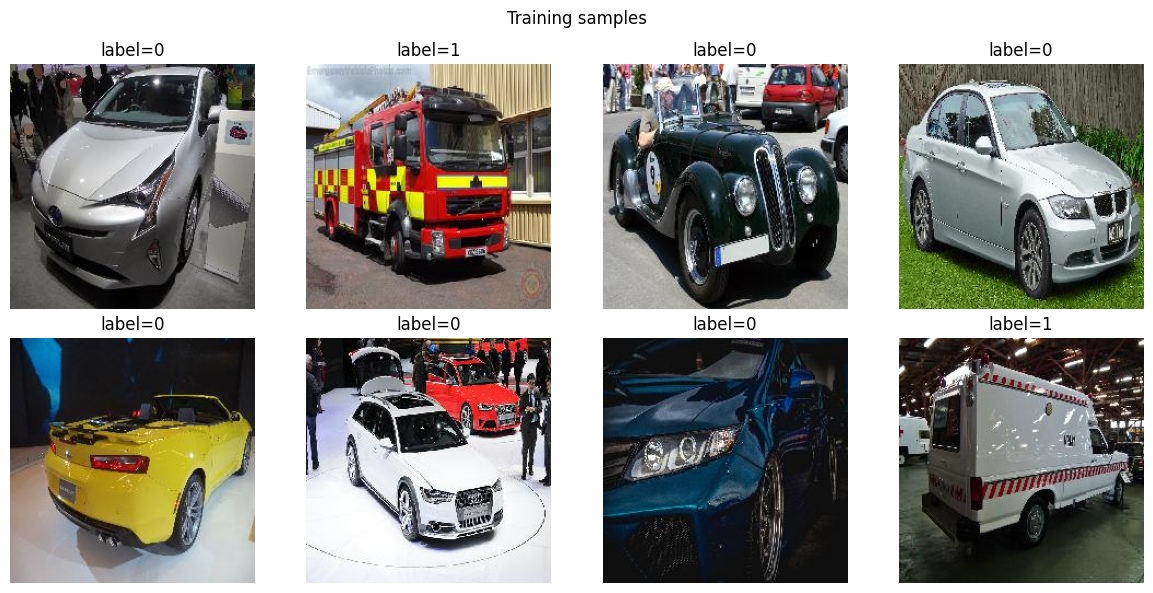

In [33]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for axis, index in zip(axes.ravel(), np.linspace(0, len(train_paths) - 1, 8, dtype=int)):
    with Image.open(train_paths[index]) as image:
        axis.imshow(image.convert("RGB"))
    label_value = index_to_label[int(y_all[index])]
    axis.set_title(f"label={label_value}")
    axis.axis("off")
plt.suptitle("Training samples")
plt.tight_layout()
plt.show()


## 2. 按 D5 原顺序划分训练集与验证集

D5 课件将 1646 条有标签数据按原顺序切为前 1481 条训练、后 165 条验证，并提交这 165 张图片的预测。这里严格复现该规则，不再把原始公开数据集中额外的 706 张未标注图片误当作课程竞赛测试集。

两个模型使用完全相同的训练/验证划分，保证准确率可比。训练集使用轻量数据增强；验证与提交图片只做确定性的 resize、crop 和 ImageNet 标准化。


In [34]:
split_index = int(len(train_paths) * 0.90)
train_indices = np.arange(split_index)
full_val_indices = np.arange(split_index, len(train_paths))
val_indices = full_val_indices.copy()

if len(full_val_indices) != EXPECTED_SUBMISSION_ROWS:
    raise ValueError(
        f"按 D5 的 90%/10% 顺序切分得到 {len(full_val_indices)} 条验证数据，"
        f"但课程竞赛要求 {EXPECTED_SUBMISSION_ROWS} 行。请确认读取的是 emergency_train.csv。"
    )

imagenet_mean = (0.485, 0.456, 0.406)
imagenet_std = (0.229, 0.224, 0.225)

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.80, 1.00), ratio=(0.85, 1.15)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])


class VehicleDataset(Dataset):
    def __init__(self, image_paths, labels=None, transform=None):
        self.image_paths = list(image_paths)
        self.labels = None if labels is None else np.asarray(labels, dtype=np.int64)
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        with Image.open(self.image_paths[index]) as image:
            image = image.convert("RGB")
            if self.transform is not None:
                image = self.transform(image)
        if self.labels is None:
            return image
        return image, int(self.labels[index])


USE_D5_VALIDATION_SUBMISSION = (
    len(full_val_indices) == EXPECTED_SUBMISSION_ROWS
    and (sample_df is None or len(sample_df) == EXPECTED_SUBMISSION_ROWS)
    and (test_df is None or len(test_df) != EXPECTED_SUBMISSION_ROWS)
)

if USE_D5_VALIDATION_SUBMISSION:
    submission_paths = [train_paths[index] for index in full_val_indices]
    print("D5 课程提交模式：预测原训练 CSV 最后 165 张图片。")
else:
    submission_paths = test_paths
    if sample_df is not None and len(sample_df) != len(submission_paths):
        raise ValueError("提交模板行数与选定的测试图片数不一致。")

if FAST_DEV_RUN:
    # 只缩短训练和验证；提交预测仍保持完整 165 行。
    train_indices = train_indices[: min(64, len(train_indices))]
    val_indices = val_indices[: min(32, len(val_indices))]

train_set = VehicleDataset(
    [train_paths[index] for index in train_indices],
    y_all[train_indices],
    train_transform,
)
val_set = VehicleDataset(
    [train_paths[index] for index in val_indices],
    y_all[val_indices],
    eval_transform,
)
test_set = VehicleDataset(submission_paths, transform=eval_transform)

BATCH_SIZE = 32 if DEVICE.type == "cuda" else 8
NUM_WORKERS = 2 if DEVICE.type == "cuda" else 0


def make_loader(dataset, shuffle, batch_size=BATCH_SIZE):
    kwargs = dict(
        dataset=dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE.type == "cuda"),
    )
    if NUM_WORKERS > 0:
        kwargs["persistent_workers"] = True
    return DataLoader(**kwargs)


train_loader = make_loader(train_set, shuffle=True)
val_loader = make_loader(val_set, shuffle=False)
test_loader = make_loader(test_set, shuffle=False)

print("训练/验证/提交预测:", len(train_set), len(val_set), len(test_set))
print("batch size:", BATCH_SIZE)


D5 课程提交模式：预测原训练 CSV 最后 165 张图片。
训练/验证/提交预测: 1481 165 165
batch size: 32


## 3. 通用训练与验证函数

损失函数直接接收模型输出的 logits，因此模型末尾不添加 Softmax。训练时启用 AMP；验证时关闭梯度。每个阶段都会恢复验证准确率最高的权重。


In [35]:
def frozen_batchnorm_eval(model):
    # 冻结参数的 BatchNorm 不更新运行均值和方差。
    for module in model.modules():
        if isinstance(module, nn.BatchNorm2d):
            parameters = list(module.parameters(recurse=False))
            if parameters and not any(parameter.requires_grad for parameter in parameters):
                module.eval()


def run_epoch(model, loader, criterion, optimizer=None):
    training = optimizer is not None
    model.train(training)
    if training:
        frozen_batchnorm_eval(model)

    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    scaler = torch.cuda.amp.GradScaler(enabled=(training and DEVICE.type == "cuda"))

    context = torch.enable_grad() if training else torch.no_grad()
    with context:
        for images, labels in loader:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            if training:
                optimizer.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):
                logits = model(images)
                loss = criterion(logits, labels)

            if training:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

            total_loss += loss.item() * labels.size(0)
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_samples += labels.size(0)

            if FAST_DEV_RUN:
                break

    return total_loss / total_samples, total_correct / total_samples


def load_state_dict_safely(path):
    try:
        return torch.load(path, map_location=DEVICE, weights_only=True)
    except TypeError:
        return torch.load(path, map_location=DEVICE)


def fit_model(model, optimizer, criterion, epochs, checkpoint_path, stage_name, initial_best=-1.0):
    history = []
    best_accuracy = initial_best
    start = time.time()

    for epoch in range(1, epochs + 1):
        train_loss, train_accuracy = run_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_accuracy = run_epoch(model, val_loader, criterion)
        history.append({
            "stage": stage_name,
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_accuracy,
            "val_loss": val_loss,
            "val_accuracy": val_accuracy,
        })

        if val_accuracy > best_accuracy:
            best_accuracy = val_accuracy
            torch.save(model.state_dict(), checkpoint_path)

        print(
            f"[{stage_name}] epoch {epoch:02d}/{epochs:02d} | "
            f"train loss {train_loss:.4f}, acc {train_accuracy:.4f} | "
            f"val loss {val_loss:.4f}, acc {val_accuracy:.4f}"
        )

        if FAST_DEV_RUN:
            break

    model.load_state_dict(load_state_dict_safely(checkpoint_path))
    elapsed = time.time() - start
    print(f"{stage_name} 完成，最佳验证准确率 {best_accuracy:.4f}，耗时 {elapsed / 60:.1f} 分钟。")
    return history, best_accuracy


## 4. 对照组：普通两层 CNN

按照 D5 课件思路，模型使用两个 `Conv2d → BatchNorm → ReLU → MaxPool` 阶段，再用全连接层完成多类别分类。输出神经元数由训练 CSV 的实际标签自动确定；`AdaptiveAvgPool2d` 用于控制参数量，避免课件示例中超大的展平层。


In [36]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((7, 7)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.35),
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.20),
            nn.Linear(128, num_classes),
        )

    def forward(self, images):
        return self.classifier(self.features(images))


baseline_model = BaselineCNN().to(DEVICE)
with torch.no_grad():
    baseline_shape = baseline_model(torch.zeros(2, 3, IMAGE_SIZE, IMAGE_SIZE, device=DEVICE)).shape
assert baseline_shape == (2, NUM_CLASSES)

baseline_criterion = nn.CrossEntropyLoss()
baseline_optimizer = torch.optim.Adam(baseline_model.parameters(), lr=1e-3)
baseline_checkpoint = OUTPUT_DIR / "baseline_cnn.pth"

print(baseline_model)
print("输出形状:", tuple(baseline_shape))
print("可训练参数:", f"{sum(p.numel() for p in baseline_model.parameters() if p.requires_grad):,}")


BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): AdaptiveAvgPool2d(output_size=(7, 7))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.35, inplace=False)
    (2): Linear(in_features=1568, out_features=128, bias=True)
    (3): ReLU(inplace=True)
    (4): Dropout(p=0.2, inplace=False)
    (5): Linear(in_features=128, out_features=2, bias=True)
  )
)
输出形状: (2, 2)
可训练参数: 206,226


In [37]:
baseline_history, baseline_best_accuracy = fit_model(
    baseline_model,
    baseline_optimizer,
    baseline_criterion,
    epochs=1 if FAST_DEV_RUN else CNN_EPOCHS,
    checkpoint_path=baseline_checkpoint,
    stage_name="Baseline CNN",
)


/tmp/ipykernel_58/78223658.py:19: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(training and DEVICE.type == "cuda"))
/tmp/ipykernel_58/78223658.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):


[Baseline CNN] epoch 01/15 | train loss 0.5899, acc 0.6989 | val loss 0.5890, acc 0.6970
[Baseline CNN] epoch 02/15 | train loss 0.4984, acc 0.7576 | val loss 0.4591, acc 0.7818
[Baseline CNN] epoch 03/15 | train loss 0.4912, acc 0.7698 | val loss 0.4638, acc 0.8000
[Baseline CNN] epoch 04/15 | train loss 0.4413, acc 0.7961 | val loss 0.4487, acc 0.7818
[Baseline CNN] epoch 05/15 | train loss 0.4495, acc 0.7941 | val loss 0.4124, acc 0.8303
[Baseline CNN] epoch 06/15 | train loss 0.4161, acc 0.8055 | val loss 0.3866, acc 0.8242
[Baseline CNN] epoch 07/15 | train loss 0.4171, acc 0.8130 | val loss 0.4432, acc 0.8121
[Baseline CNN] epoch 08/15 | train loss 0.4100, acc 0.8055 | val loss 0.3698, acc 0.8303
[Baseline CNN] epoch 09/15 | train loss 0.3790, acc 0.8238 | val loss 0.3769, acc 0.8061
[Baseline CNN] epoch 10/15 | train loss 0.3891, acc 0.8265 | val loss 0.3953, acc 0.8242
[Baseline CNN] epoch 11/15 | train loss 0.3609, acc 0.8305 | val loss 0.3529, acc 0.8606
[Baseline CNN] epoch 

## 5. 迁移学习：VGG16-BN 冻结分类头训练

这里使用 `VGG16_BN_Weights.DEFAULT` 加载 ImageNet 权重。先冻结所有已有参数，只把最后的 1000 类分类层替换为本数据集的类别数并训练；这样不会在新分类头尚未收敛时破坏预训练特征。


In [38]:
def load_pretrained_vgg16_bn():
    weights = VGG16_BN_Weights.DEFAULT
    weight_filename = Path(weights.url).name
    local_candidates = []
    if Path("/kaggle/input").exists():
        local_candidates = list(Path("/kaggle/input").rglob(weight_filename))

    if local_candidates:
        weight_path = sorted(local_candidates)[0]
        print("使用 Kaggle Input 中的 VGG16-BN 权重:", weight_path)
        model = models.vgg16_bn(weights=None)
        try:
            state = torch.load(weight_path, map_location="cpu", weights_only=True)
        except TypeError:
            state = torch.load(weight_path, map_location="cpu")
        model.load_state_dict(state)
        return model

    try:
        print("未发现本地权重，尝试由 TorchVision 下载:", weights.url)
        return models.vgg16_bn(weights=weights)
    except Exception as error:
        raise RuntimeError(
            "无法加载 ImageNet 预训练 VGG16-BN 权重。请打开 Kaggle Internet 后重新运行，"
            f"或把 {weight_filename} 作为 Dataset/Model 添加到 Kaggle Input。"
        ) from error


transfer_model = load_pretrained_vgg16_bn()
for parameter in transfer_model.parameters():
    parameter.requires_grad = False

in_features = transfer_model.classifier[-1].in_features
transfer_model.classifier[-1] = nn.Linear(in_features, NUM_CLASSES)
transfer_model = transfer_model.to(DEVICE)

head_criterion = nn.CrossEntropyLoss()
head_optimizer = torch.optim.AdamW(
    transfer_model.classifier[-1].parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)
head_checkpoint = OUTPUT_DIR / "vgg16_bn_head.pth"

with torch.no_grad():
    transfer_shape = transfer_model(torch.zeros(2, 3, IMAGE_SIZE, IMAGE_SIZE, device=DEVICE)).shape
assert transfer_shape == (2, NUM_CLASSES)

print("输出形状:", tuple(transfer_shape))
print("可训练参数:", f"{sum(p.numel() for p in transfer_model.parameters() if p.requires_grad):,}")


未发现本地权重，尝试由 TorchVision 下载: https://download.pytorch.org/models/vgg16_bn-6c64b313.pth
输出形状: (2, 2)
可训练参数: 8,194


In [39]:
head_history, head_best_accuracy = fit_model(
    transfer_model,
    head_optimizer,
    head_criterion,
    epochs=1 if FAST_DEV_RUN else HEAD_EPOCHS,
    checkpoint_path=head_checkpoint,
    stage_name="VGG16 frozen head",
)


/tmp/ipykernel_58/78223658.py:19: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(training and DEVICE.type == "cuda"))
/tmp/ipykernel_58/78223658.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):


[VGG16 frozen head] epoch 01/10 | train loss 0.2876, acc 0.8690 | val loss 0.2185, acc 0.9212
[VGG16 frozen head] epoch 02/10 | train loss 0.1960, acc 0.9271 | val loss 0.1995, acc 0.9333
[VGG16 frozen head] epoch 03/10 | train loss 0.1763, acc 0.9392 | val loss 0.2088, acc 0.9273
[VGG16 frozen head] epoch 04/10 | train loss 0.1806, acc 0.9291 | val loss 0.1873, acc 0.9273
[VGG16 frozen head] epoch 05/10 | train loss 0.1468, acc 0.9453 | val loss 0.1982, acc 0.9333
[VGG16 frozen head] epoch 06/10 | train loss 0.1660, acc 0.9365 | val loss 0.1951, acc 0.9333
[VGG16 frozen head] epoch 07/10 | train loss 0.1495, acc 0.9433 | val loss 0.1915, acc 0.9333
[VGG16 frozen head] epoch 08/10 | train loss 0.1536, acc 0.9392 | val loss 0.1927, acc 0.9333
[VGG16 frozen head] epoch 09/10 | train loss 0.1455, acc 0.9399 | val loss 0.2072, acc 0.9273
[VGG16 frozen head] epoch 10/10 | train loss 0.1448, acc 0.9453 | val loss 0.2022, acc 0.9455
VGG16 frozen head 完成，最佳验证准确率 0.9455，耗时 1.1 分钟。


## 6. 小学习率微调最后一个卷积块

分类头已训练后，解冻 VGG16-BN 的第 5 个卷积块（`features[34:]`）。分类头使用 `1e-4`，预训练卷积块使用更小的 `1e-5`，以减少对 ImageNet 特征的破坏。


In [40]:
for parameter in transfer_model.features[34:].parameters():
    parameter.requires_grad = True

finetune_optimizer = torch.optim.AdamW(
    [
        {"params": transfer_model.features[34:].parameters(), "lr": 1e-5},
        {"params": transfer_model.classifier[-1].parameters(), "lr": 1e-4},
    ],
    weight_decay=1e-4,
)
finetune_checkpoint = OUTPUT_DIR / "vgg16_bn_finetuned.pth"

# 若微调没有超过冻结阶段，也保留冻结阶段的最佳权重。
torch.save(transfer_model.state_dict(), finetune_checkpoint)

print("微调可训练参数:", f"{sum(p.numel() for p in transfer_model.parameters() if p.requires_grad):,}")

finetune_history, transfer_best_accuracy = fit_model(
    transfer_model,
    finetune_optimizer,
    head_criterion,
    epochs=1 if FAST_DEV_RUN else FINETUNE_EPOCHS,
    checkpoint_path=finetune_checkpoint,
    stage_name="VGG16 fine-tune",
    initial_best=head_best_accuracy,
)


微调可训练参数: 7,090,690


/tmp/ipykernel_58/78223658.py:19: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(training and DEVICE.type == "cuda"))
/tmp/ipykernel_58/78223658.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):


[VGG16 fine-tune] epoch 01/05 | train loss 0.2018, acc 0.9122 | val loss 0.2277, acc 0.8970
[VGG16 fine-tune] epoch 02/05 | train loss 0.1615, acc 0.9392 | val loss 0.2157, acc 0.9091
[VGG16 fine-tune] epoch 03/05 | train loss 0.1422, acc 0.9419 | val loss 0.2068, acc 0.9091
[VGG16 fine-tune] epoch 04/05 | train loss 0.1094, acc 0.9629 | val loss 0.2043, acc 0.9030
[VGG16 fine-tune] epoch 05/05 | train loss 0.0983, acc 0.9642 | val loss 0.1998, acc 0.9273
VGG16 fine-tune 完成，最佳验证准确率 0.9455，耗时 0.6 分钟。


## 7. 准确率对比与最终验证结果

下表直接回答 D5 要求的“基础模型与迁移学习加微调正确率对比”。同时绘制训练曲线，并输出微调模型的分类报告和混淆矩阵。


In [41]:
comparison = pd.DataFrame({
    "model": ["Baseline CNN", "VGG16-BN transfer + fine-tune"],
    "best_validation_accuracy": [baseline_best_accuracy, transfer_best_accuracy],
})
comparison["best_validation_accuracy_percent"] = (
    comparison["best_validation_accuracy"] * 100
).round(2)
comparison


,model,best_validation_accuracy,best_validation_accuracy_percent
0,Baseline CNN,0.860606,86.06
1,VGG16-BN transfer + fine-tune,0.945455,94.55


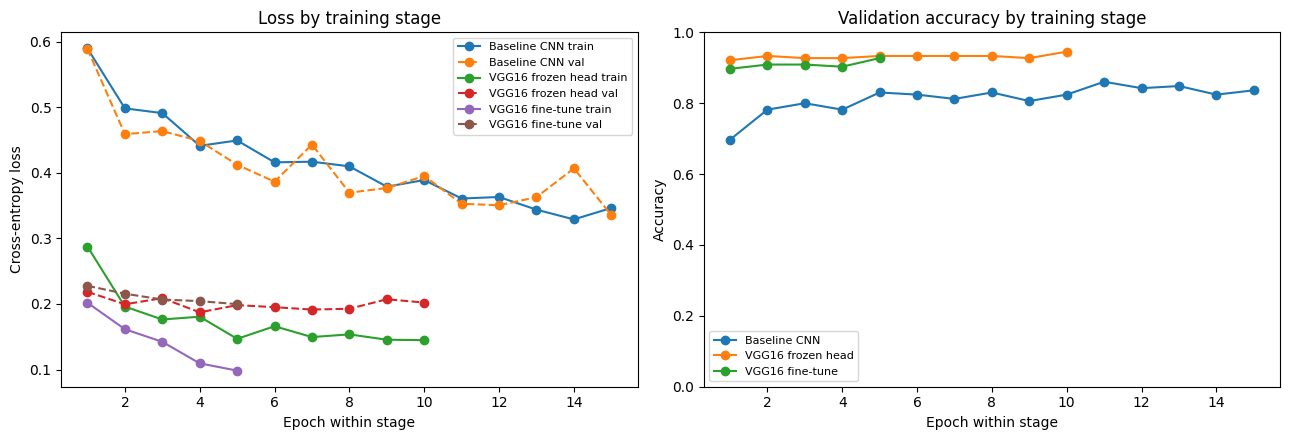

In [42]:
history_df = pd.DataFrame(baseline_history + head_history + finetune_history)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for stage, group in history_df.groupby("stage", sort=False):
    x = np.arange(1, len(group) + 1)
    axes[0].plot(x, group["train_loss"], marker="o", label=f"{stage} train")
    axes[0].plot(x, group["val_loss"], marker="o", linestyle="--", label=f"{stage} val")
    axes[1].plot(x, group["val_accuracy"], marker="o", label=stage)

axes[0].set_title("Loss by training stage")
axes[0].set_xlabel("Epoch within stage")
axes[0].set_ylabel("Cross-entropy loss")
axes[0].legend(fontsize=8)

axes[1].set_title("Validation accuracy by training stage")
axes[1].set_xlabel("Epoch within stage")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


              precision    recall  f1-score   support

           0     0.9541    0.9630    0.9585       108
           1     0.9286    0.9123    0.9204        57

    accuracy                         0.9455       165
   macro avg     0.9413    0.9376    0.9394       165
weighted avg     0.9453    0.9455    0.9453       165



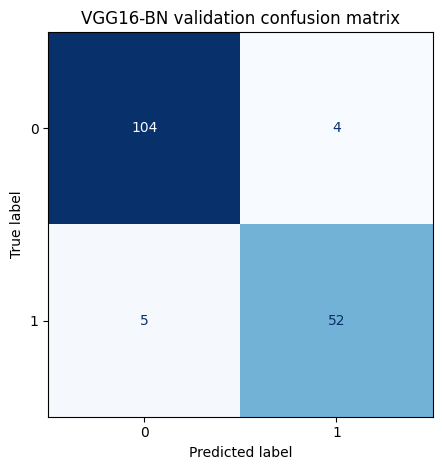

In [43]:
def collect_predictions(model, loader):
    model.eval()
    all_predictions = []
    all_targets = []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE, non_blocking=True)
            logits = model(images)
            all_predictions.extend(logits.argmax(dim=1).cpu().numpy().tolist())
            all_targets.extend(labels.numpy().tolist())
    return np.asarray(all_targets), np.asarray(all_predictions)


val_targets, val_predictions = collect_predictions(transfer_model, val_loader)
target_names = [str(index_to_label[index]) for index in range(NUM_CLASSES)]

print(classification_report(
    val_targets,
    val_predictions,
    labels=list(range(NUM_CLASSES)),
    target_names=target_names,
    digits=4,
    zero_division=0,
))

ConfusionMatrixDisplay.from_predictions(
    val_targets,
    val_predictions,
    labels=list(range(NUM_CLASSES)),
    display_labels=target_names,
    cmap="Blues",
    colorbar=False,
)
plt.title("VGG16-BN validation confusion matrix")
plt.tight_layout()
plt.show()


## 8. 生成课程竞赛的 165 行提交文件

最终使用微调后的 VGG16-BN。预测时将原图与水平翻转图的 logits 求平均。

- D5 课程模式：按原顺序预测 `emergency_train.csv` 最后 165 张图片；
- 如果实际数据提供了 165 行测试 CSV，则使用该测试集；
- 若存在 sample submission，则保留它的 ID、列名和顺序；否则严格生成 `id,label`。


In [44]:
def predict_test(model, loader):
    model.eval()
    predictions = []
    with torch.no_grad():
        for images in loader:
            images = images.to(DEVICE, non_blocking=True)
            logits_original = model(images)
            logits_flipped = model(torch.flip(images, dims=[3]))
            logits = (logits_original + logits_flipped) / 2
            predictions.extend(logits.argmax(dim=1).cpu().numpy().tolist())
    return np.asarray(predictions, dtype=np.int64)


test_prediction_indices = predict_test(transfer_model, test_loader)
test_prediction_values = np.asarray(
    [index_to_label[int(index)] for index in test_prediction_indices]
)

print("测试预测数:", len(test_prediction_values))
print("预测分布:", pd.Series(test_prediction_values).value_counts().sort_index().to_dict())


测试预测数: 165
预测分布: {0: 111, 1: 54}


In [45]:
if sample_df is not None:
    submission = sample_df.copy()
    if submission.shape[1] >= 2:
        prediction_col = submission.columns[-1]
    else:
        prediction_col = LABEL_COL
    submission[prediction_col] = test_prediction_values
else:
    # 本次课程竞赛明确要求 id,label；若 test.csv 提供 id 列则保留，否则按测试顺序编号。
    if test_df is not None and "id" in normalized_columns(test_df):
        id_col = normalized_columns(test_df)["id"]
        submission_ids = test_df[id_col].to_numpy()
    else:
        submission_ids = np.arange(len(test_prediction_values))
    submission = pd.DataFrame({
        "id": submission_ids,
        "label": test_prediction_values,
    })

if len(submission) != len(test_prediction_values):
    raise ValueError("submission 行数与预测数不一致。")
if USE_D5_VALIDATION_SUBMISSION and len(submission) != EXPECTED_SUBMISSION_ROWS:
    raise ValueError(
        f"课程 submission 必须为 {EXPECTED_SUBMISSION_ROWS} 行，实际为 {len(submission)} 行。"
    )
if submission.isna().any().any():
    raise ValueError("submission 中存在缺失值。")

submission_path = OUTPUT_DIR / "submission.csv"
submission.to_csv(submission_path, index=False)

print("提交文件:", submission_path)
print("形状:", submission.shape)
print("列名:", list(submission.columns))
display(submission.head())


提交文件: /kaggle/working/submission.csv
形状: (165, 2)
列名: ['id', 'label']


,id,label
0,0,0
1,1,0
2,2,0
3,3,0
4,4,0


## 9. 提交前检查

Run All 完成后，请确认：

- `FAST_DEV_RUN` 为 `False`；
- 对比表中同时出现普通 CNN 和 VGG16-BN 的验证准确率；
- 最后一格显示形状 `(165, 2)`，列名为 `id,label`；
- 在右侧 **Output** 下载或直接提交 `submission.csv`。

Notebook 同时保留 `baseline_cnn.pth`、`vgg16_bn_head.pth` 和 `vgg16_bn_finetuned.pth`，便于复现实验与报告结果。
